In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import time

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                120        1
   valid     1000                120        1
    test      500                120        1



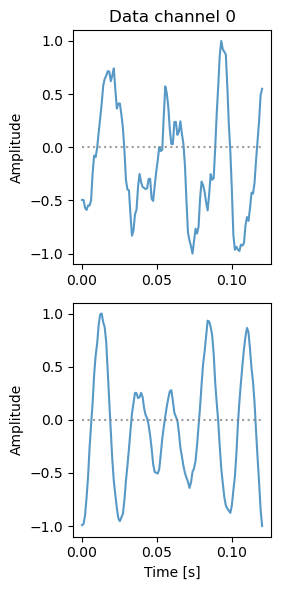

In [2]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir               = '../../data/baselines/tesla_train_trans'
timeseries_ndim       = 1
timeseries_nsample    = 120
timestep              = 0.001

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep, plot_ndata=2)


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                120        1
   valid     1000                120        1
    test      500                120        1



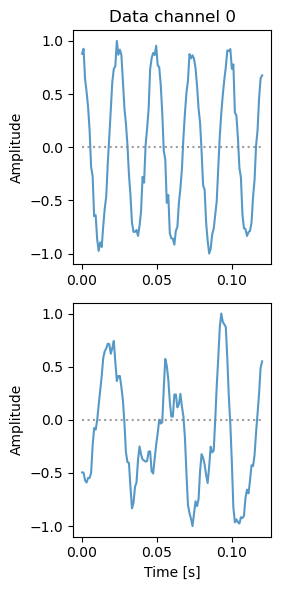

In [3]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir               = '../../data/baselines/tesla_train_mixed'
timeseries_ndim       = 1
timeseries_nsample    = 120
timestep              = 0.001

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep, plot_ndata=2)

In [4]:
# --! load a trained stationary model --!

# --! ensure reproducible results
seed = 123
torch.manual_seed(seed)

model = torch.load('../../models/baselines/tesla_kind_stat.pt', weights_only=False)

# --! continue training the model --!

model.train()

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/baselines/tesla_train_stat',
    'transdatadir'          : '../../data/baselines/tesla_train_trans',
    'mixdatadir'            : '../../data/baselines/tesla_train_mixed',
    'timeseries_nsample'    : timeseries_nsample,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

loss = []

t_start = time.time()

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

t_end     = time.time()
t_elapsed = t_end - t_start
print(f'inf >> training time elapsed: {t_elapsed:.1f} seconds')

inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering transient mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering transient variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training fil

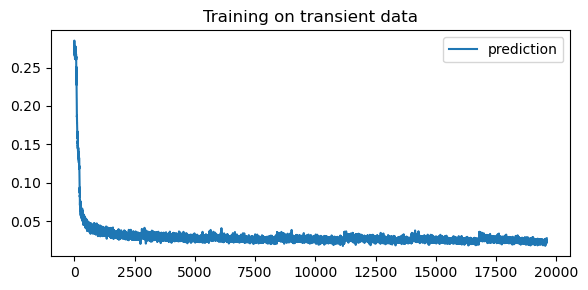

In [5]:
# --! plot training statistics --!

with torch.no_grad():
    loss_trans = loss[1]

    plt.figure(figsize=(6, 3))

    plt.title('Training on transient data')
    plt.plot(loss_trans[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
# --! switch the trained model to evaluation mode --!

model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var): Linear(in_features=8, out_features=8, bias=False)
    (pre_mean_dec): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=40, bias=Tru

In [7]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/tesla_test'
timeseries_nsample = 250_000

mse_stat, mse_trans, mse_blend = utils_plot.plot_mse(model, datadir, timeseries_nsample)


inf >> forecasting results:

         mse      index      value
 -----------   --------   --------
  best blend     154525      0.001
 worst blend      34407      1.137
   avg blend         na      0.081
                                  
   best stat     219569      0.006
  worst stat      81688      0.066
    avg stat         na      0.469
                                  
  best trans     168100      0.012
 worst trans      27417      0.630
   avg trans         na      0.076

inf >> mean alpha is 0.17



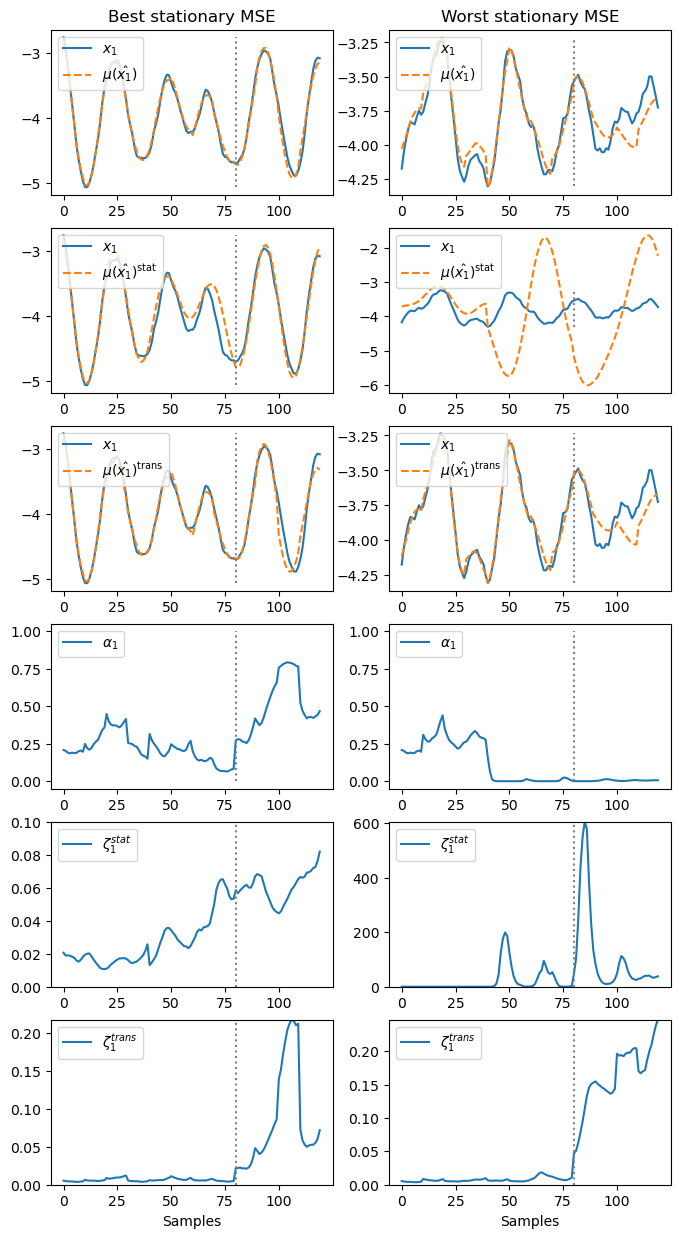

In [8]:
utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_stat, mse_type='stationary',
    datasaved=True, savedir='../../savedata/baselines/tesla')

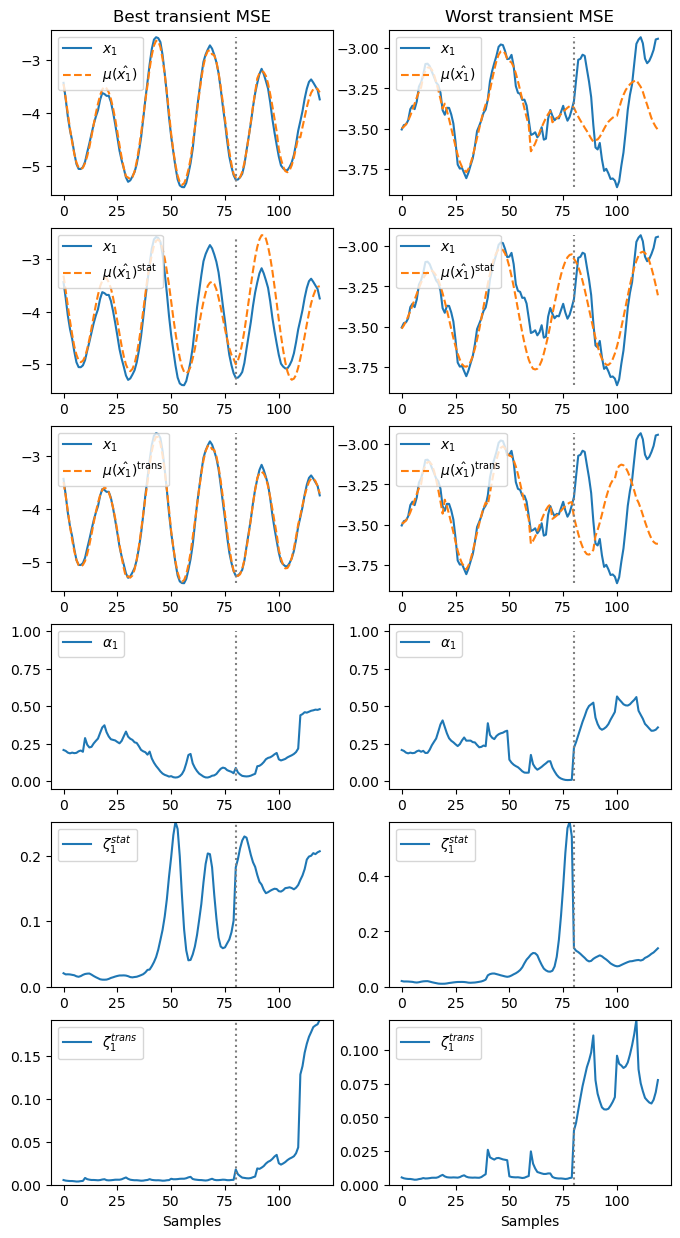

In [9]:
utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_trans, mse_type='transient',
    datasaved=True, savedir='../../savedata/baselines/tesla')

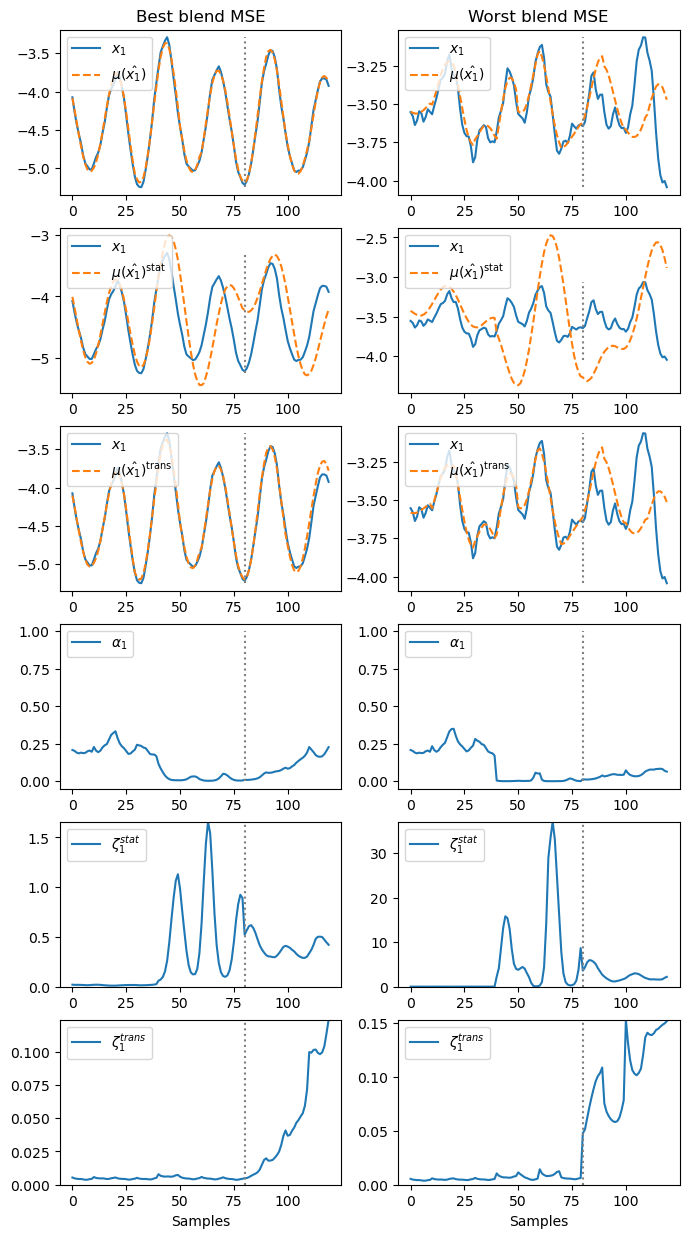

In [10]:
utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    datasaved=True, savedir='../../savedata/baselines/tesla')

In [11]:
# --! save the trained model --!

modelsaved = True

if modelsaved:
    torch.save(model, '../../models/baselines/tesla_kind_trans.pt')